In [8]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# EDA를 통한 각 지표 확인
## 데이터 구조 점검 및 변수 이해
### 데이터 준비

In [2]:
import pandas as pd

In [3]:
# 메인 - 농산물 거래 데이터
df = pd.read_csv('datasets/마늘_이상치제거_주간기준_등급코드.csv', encoding='cp949')
# 외생변수 데이터
df_grow = pd.read_csv('datasets/holiday_작기_수정완료_utf-8_최종.csv', encoding='utf-8')

In [20]:
# 메인 - item_code 생성
df['item_code'] = '1209'  # 거래데이터에는 대분류 코드가 없고 한 종류만 있음
# 외생변수 - item_code 데이터타입 및 자리수 조정
df_grow['item_code'] = df_grow['item_code'].astype(str) 
df_grow['item_code'] = df_grow['item_code'].str.zfill(4)

,주차,연월일,품목코드,품목명,품종코드,품종명,등급코드,등급이름,총금액(원),총거래량(kg),...,명절지수,작기정보,일평균기온,최고기온,최저기온,평균상대습도,강수량(mm),1시간최고강수량(mm),weekno,item_code
0,2018-01-01~2018-01-07,2018-01-02,09,마늘,05,풋마늘,12,중,114900.0,30.0,...,NaN,NaN,3.1,8.9,-3.3,59.8,-9.0,-9.0,2018_01,0905
1,2018-01-01~2018-01-07,2018-01-02,09,마늘,99,기타마늘,12,중,11718.0,2.0,...,NaN,NaN,-1.8,1.8,-4.3,42.0,-9.0,-9.0,2018_01,0999
2,2018-01-01~2018-01-07,2018-01-02,09,마늘,99,기타마늘,12,중,146497.0,25.0,...,NaN,NaN,-1.8,1.8,-4.3,42.0,-9.0,-9.0,2018_01,0999
3,2018-01-01~2018-01-07,2018-01-02,09,마늘,17,마늘쫑(수입),13,저,45802.0,20.0,...,NaN,NaN,-1.8,1.8,-4.3,42.0,-9.0,-9.0,2018_01,0917
4,2018-01-01~2018-01-07,2018-01-02,09,마늘,17,마늘쫑(수입),13,저,184000.0,64.0,...,NaN,NaN,0.7,6.7,-3.2,74.6,0.0,-9.0,2018_01,0917


In [10]:
# 메인 데이터프레임
# weekno 열을 만들고 주차 표기를 통일시켜 merge 준비
def get_week_of_year(date):
    date = pd.to_datetime(date)
    year = date.year
    week_number = date.isocalendar().week
    return f"{year}_{week_number:02d}"

df['weekno'] = df['연월일'].apply(get_week_of_year)

In [15]:
# 외생변수 데이터프레임
# weekno 열을 만들고 주차 표기를 통일시켜 merge 준비
import re

def format_week_string(week_str):
    # '년'과 '째주' 사이의 숫자와 앞의 연도 숫자를 찾습니다.
    match = re.search(r'(\d{4})년\s*(\d{1,2})째주', week_str)
    if match:
        year = match.group(1)
        week = match.group(2)
        # 주차를 항상 두 자리 숫자로 포맷팅합니다 (예: '1' -> '01')
        return f"{year}_{int(week):02d}"
    return week_str # 매칭되지 않으면 원본 반환

df_grow['weekno'] = df_grow['week_no'].apply(format_week_string)

In [22]:
# 기 생성된 휴일여부	명절지수	작기정보 칼럼 삭제
df.drop(columns=['휴일여부', '명절지수', '작기정보'], inplace=True)

In [31]:
# 병합하기
merged_df  = pd.merge( df,
                    df_grow[['weekno', 'item_code', 'holiday_flag', 'holiday_score', 'grow_score']],
                    left_on=['weekno', 'item_code'],
                    right_on=['weekno', 'item_code'],
                    how='left'
                )
merged_df.head()

,주차,연월일,품목코드,품목명,품종코드,품종명,등급코드,등급이름,총금액(원),총거래량(kg),...,최고기온,최저기온,평균상대습도,강수량(mm),1시간최고강수량(mm),weekno,item_code,holiday_flag,holiday_score,grow_score
0,2018-01-01~2018-01-07,2018-01-02,09,마늘,05,풋마늘,12,중,114900.0,30.0,...,8.9,-3.3,59.8,-9.0,-9.0,2018_01,1201,1,0.0,0.0
1,2018-01-01~2018-01-07,2018-01-02,09,마늘,99,기타마늘,12,중,11718.0,2.0,...,1.8,-4.3,42.0,-9.0,-9.0,2018_01,1201,1,0.0,0.0
2,2018-01-01~2018-01-07,2018-01-02,09,마늘,99,기타마늘,12,중,146497.0,25.0,...,1.8,-4.3,42.0,-9.0,-9.0,2018_01,1201,1,0.0,0.0
3,2018-01-01~2018-01-07,2018-01-02,09,마늘,17,마늘쫑(수입),13,저,45802.0,20.0,...,1.8,-4.3,42.0,-9.0,-9.0,2018_01,1201,1,0.0,0.0
4,2018-01-01~2018-01-07,2018-01-02,09,마늘,17,마늘쫑(수입),13,저,184000.0,64.0,...,6.7,-3.2,74.6,0.0,-9.0,2018_01,1201,1,0.0,0.0


In [57]:
# 강수량, 1시간최고 강수량은 결측치(-9) 혹은 비가 안옴(0)이 많아 0 이하는 0으로 처리
# merged_df['강수량(mm)'] = merged_df['강수량(mm)'<=0].count()
merged_df.loc[merged_df['강수량(mm)']<=0, '강수량(mm)'] = 0
merged_df.loc[merged_df['1시간최고강수량(mm)']<=0, '1시간최고강수량(mm)'] = 0

In [58]:
# 일간 거래 데이터 (필요한 열만 사용)
df_daily_galic = merged_df.loc[:, ['연월일', '품종코드', '등급코드', '총거래량(kg)','주간평균단가(원)','직팜산지코드','일평균기온','최고기온','최저기온','평균상대습도','강수량(mm)','1시간최고강수량(mm)', 'holiday_flag', 'holiday_score','grow_score', '총금액(원)']]
df_daily_galic.head()

,연월일,품종코드,등급코드,총거래량(kg),주간평균단가(원),직팜산지코드,일평균기온,최고기온,최저기온,평균상대습도,강수량(mm),1시간최고강수량(mm),holiday_flag,holiday_score,grow_score,총금액(원)
0,2018-01-02,05,12,30.0,4874.018048,1131,3.1,8.9,-3.3,59.8,0.0,0.0,1,0.0,0.0,114900.0
1,2018-01-02,99,12,2.0,4874.018048,1000,-1.8,1.8,-4.3,42.0,0.0,0.0,1,0.0,0.0,11718.0
2,2018-01-02,99,12,25.0,4874.018048,1000,-1.8,1.8,-4.3,42.0,0.0,0.0,1,0.0,0.0,146497.0
3,2018-01-02,17,13,20.0,4874.018048,1000,-1.8,1.8,-4.3,42.0,0.0,0.0,1,0.0,0.0,45802.0
4,2018-01-02,17,13,64.0,4874.018048,1107,0.7,6.7,-3.2,74.6,0.0,0.0,1,0.0,0.0,184000.0


In [63]:
# 주간 거래 데이터 병합
df_galic = merged_df.loc[:, ['weekno', '품종코드', '등급코드', '총금액(원)', '총거래량(kg)','직팜산지코드','일평균기온','최고기온','최저기온','평균상대습도','강수량(mm)','1시간최고강수량(mm)', 'holiday_flag', 'holiday_score','grow_score']]
df_weekly_galic = df_galic.groupby(['weekno', '품종코드', '등급코드', '직팜산지코드']).agg({
    '총금액(원)' : 'sum', 
    '총거래량(kg)' : 'sum', 
    '일평균기온': 'mean', 
    '최고기온': 'max', 
    '최저기온' : 'min', 
    '평균상대습도' : 'mean', 
    '강수량(mm)' : 'sum', 
    '1시간최고강수량(mm)' : 'sum', 
    'holiday_flag' : 'sum', 
    'holiday_score' : 'sum', 
    'grow_score' : 'sum'
}).reset_index()

# 주간 단가 계산
df_weekly_galic['평균단가(원)'] = round(df_weekly_galic_['총금액(원)']/df_weekly_galic_['총거래량(kg)'])

In [64]:
## 필요시 사용하세요
## 모델링시 시간변수가 필요한 경우가 발생하여 추가합니다

# weekno 분리
def format_week_string(week_str):
    # '년'과 '째주' 사이의 숫자와 앞의 연도 숫자를 찾습니다.
    # match = re.search(r'(\d{4})년\s*(\d{1,2})째주', week_str)
    match = re.search(r'(\d{4})_(\d{1,2})', week_str)
    if match:
        year = match.group(1)
        week = match.group(2)
        # 주차를 항상 두 자리 숫자로 포맷팅합니다 (예: '1' -> '01')
        return year, week
    return week_str # 매칭되지 않으면 원본 반환

df_weekly_galic['year'], df_weekly_galic['week'] = zip(*df_weekly_galic['weekno'].apply(format_week_string))

# 주간 시작일 입력 (시계열 특성 - prophet 대비)
import datetime

def year_week_to_date(year, week):
    # ISO 주차는 매년 첫 번째 주의 월요일이 기준
    return datetime.date.fromisocalendar(int(year), int(week), 1)  # 1: 월요일

df_weekly_galic['week_start'] = df_weekly_galic.apply(lambda row: year_week_to_date(row['year'], row['week']), axis=1)
df_weekly_galic['week_start'] = pd.to_datetime(df_weekly_galic['week_start'])
df_weekly_galic.drop(columns='weekno', inplace=True)

(121918, 16)


,weekno,품종코드,등급코드,직팜산지코드,총금액(원),총거래량(kg),일평균기온,최고기온,최저기온,평균상대습도,강수량(mm),1시간최고강수량(mm),holiday_flag,holiday_score,grow_score,평균단가(원)
0,2018_01,00,11,1000,740240.0,118.0,-4.45,1.6,-10.5,43.325,0.0,0.0,4,0.0,0.0,6273.0
1,2018_01,00,13,1030,50400.0,15.0,-3.90,-1.0,-6.9,62.500,0.0,0.0,1,0.0,0.0,3360.0
2,2018_01,01,11,1121,23680.0,4.0,-0.50,6.8,-8.2,41.600,0.0,0.0,1,0.0,0.0,5920.0
3,2018_01,01,12,1121,24773520.0,5506.0,1.60,8.8,-5.2,32.200,0.0,0.0,4,0.0,0.0,4499.0
4,2018_01,01,12,1138,17180000.0,3200.0,1.42,6.5,-8.3,35.720,0.0,0.0,5,0.0,0.0,5369.0


In [66]:
# 저장
df_daily_galic.to_csv('datasets/trade_daily_galic.csv', encoding='cp949', index=False)
df_weekly_galic.to_csv('datasets/trade_weekly_galic.csv', encoding='cp949', index=False)

# 샘플파일 생성 (chat과 편안한 상담용 )
df_daily_galic_sample = df_daily_galic.iloc[:100]
df_daily_galic_sample.to_csv('datasets/trade_daily_galic_sample.csv', encoding='cp949', index=False)
df_weekly_galic_sample = df_weekly_galic.iloc[:100]
df_weekly_galic_sample.to_csv('datasets/trade_weekly_galic_sample.csv', encoding='cp949', index=False)

## EDA

# 모델링

## 아묻따 랜덤포레스트
1. 학습/검증데이터 분리
2. 모델학습
3. 예측성능평가(RMSE)
4. 변수 중요도 시각화

In [3]:
import pandas as pd
import numpy as np

In [4]:
df_weekly_galic = pd.read_csv('datasets/trade_weekly_galic.csv', encoding='cp949')

In [5]:
df_weekly_galic

,weekno,품종코드,등급코드,직팜산지코드,총거래량(kg),일평균기온,최고기온,최저기온,평균상대습도,강수량(mm),1시간최고강수량(mm),holiday_flag,holiday_score,grow_score,year,week,week_start,평균단가(원)
0,2018_01,0,11,1000,118.0,-4.450000,1.6,-10.5,43.325000,0.0,0.0,4,0.0,0.0,2018,1,2018-01-01,6273.0
1,2018_01,0,13,1030,15.0,-3.900000,-1.0,-6.9,62.500000,0.0,0.0,1,0.0,0.0,2018,1,2018-01-01,3360.0
2,2018_01,1,11,1121,4.0,-0.500000,6.8,-8.2,41.600000,0.0,0.0,1,0.0,0.0,2018,1,2018-01-01,5920.0
3,2018_01,1,12,1121,5506.0,1.600000,8.8,-5.2,32.200000,0.0,0.0,4,0.0,0.0,2018,1,2018-01-01,4499.0
4,2018_01,1,12,1138,3200.0,1.420000,6.5,-8.3,35.720000,0.0,0.0,5,0.0,0.0,2018,1,2018-01-01,5369.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121913,2025_22,99,13,1135,44.5,16.700000,22.9,12.8,75.100000,0.0,0.0,1,0.0,0.0,2025,22,2025-05-26,2944.0
121914,2025_22,99,13,1157,54.5,17.916667,28.5,9.6,69.616667,0.0,0.0,6,0.0,0.0,2025,22,2025-05-26,2404.0
121915,2025_22,99,13,1158,1642.0,19.027273,27.7,11.8,66.381818,0.0,0.0,11,0.0,0.0,2025,22,2025-05-26,1981.0
121916,2025_22,99,13,1159,1880.2,17.141176,23.3,13.2,77.376471,2.4,2.4,17,0.0,0.0,2025,22,2025-05-26,2192.0


In [7]:
df_weekly_galic['등급코드'].value_counts()

등급코드
12    49593
13    43539
11    26037
20     2749
Name: count, dtype: int64

In [171]:
print(df_weekly_galic.isna().sum())  # 대체로 산지가 없거나 수입산인 경우 기후 데이터 없음
df_weekly_galic_drop = df_weekly_galic.dropna()

weekno              0
품종코드                0
등급코드                0
직팜산지코드              0
총거래량(kg)            0
일평균기온            3087
최고기온             3087
최저기온             3087
평균상대습도           3087
강수량(mm)             0
1시간최고강수량(mm)        0
holiday_flag        0
holiday_score       0
grow_score          0
year                0
week                0
week_start          0
평균단가(원)             0
dtype: int64


In [162]:
df_weekly_galic['품종코드'].dtypes

dtype('int64')

In [163]:
# 범주형 변수 인코딩.. 생략, int가 숫자가 안되는 경우 숫자로는 맞춰본다
df_weekly_galic_drop.품종코드 = df_weekly_galic_drop.품종코드.astype(np.int64)
print(df_weekly_galic_drop.품종코드.dtypes, df_weekly_galic_drop.등급코드.dtypes, df_weekly_galic_drop.직팜산지코드.dtypes)

int64 int64 int64


In [164]:
# 학습/검증데이터 분리
train_set = df_weekly_galic_drop[df_weekly_galic_drop['weekno'] < '2024_25']
test_set = df_weekly_galic_drop[df_weekly_galic_drop['weekno'] >= '2024_25']

train_X = train_set.iloc[:, :-1]
train_y = train_set.iloc[:, -1]
test_X = test_set.iloc[:, :-1]
test_y = test_set.iloc[:, -1]

## 1차 - 
- RMSE: 879.71 원 
- R² Score (결정계수) : 0.8422  (1에 가까울수록 좋음, 0 이하이면 무의미)
- y_pred 평균값 : 4401, test_y 평균값 : 4784
- 실제값이 널뛰기를 겁나게 함. --> 타겟 변수 정규화 및 독립변수들을 스케일(순차적으로)
- 산지/등급/품종을 원핫 인코딩을 해볼것인가?
- 최소리프 샘플수 줄이기

In [108]:
%%time
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,         # 트리 300개 (조금 안정적)
    max_depth=20,             # 트리 깊이 제한 (없으면 과적합 가능)
    min_samples_leaf=3,       # 리프 노드 최소 샘플 수
    max_features='sqrt',      # 피처의 제곱근만 고려 (기본값)
    n_jobs=-1,                # 모든 CPU 코어 사용
    random_state=77           # 결과 재현 가능성 확보
)
model.fit(train_X, train_y)

CPU times: total: 1min 8s
Wall time: 11.2 s


RandomForestRegressor(max_depth=20, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=300, n_jobs=-1, random_state=77)

In [110]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(test_X)
rmse = mean_squared_error(test_y, y_pred, squared=False)
print(f"RMSE: {rmse:.2f} 원")

RMSE: 879.71 원


C:\Users\user\anaconda3\envs\do_api_env\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [116]:
y_pred.mean(), test_y.mean()

(4401.377615373424, 4784.437553832902)

In [112]:
from sklearn.metrics import r2_score

r2 = r2_score(test_y, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.8422


In [114]:
# 시각화 설정
%config InlineBackend.figure_format='retina'  
#한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False)  # 축의 - 깨짐 방지
# 경고 메세지 안보이게
import warnings
warnings.filterwarnings(action='ignore')

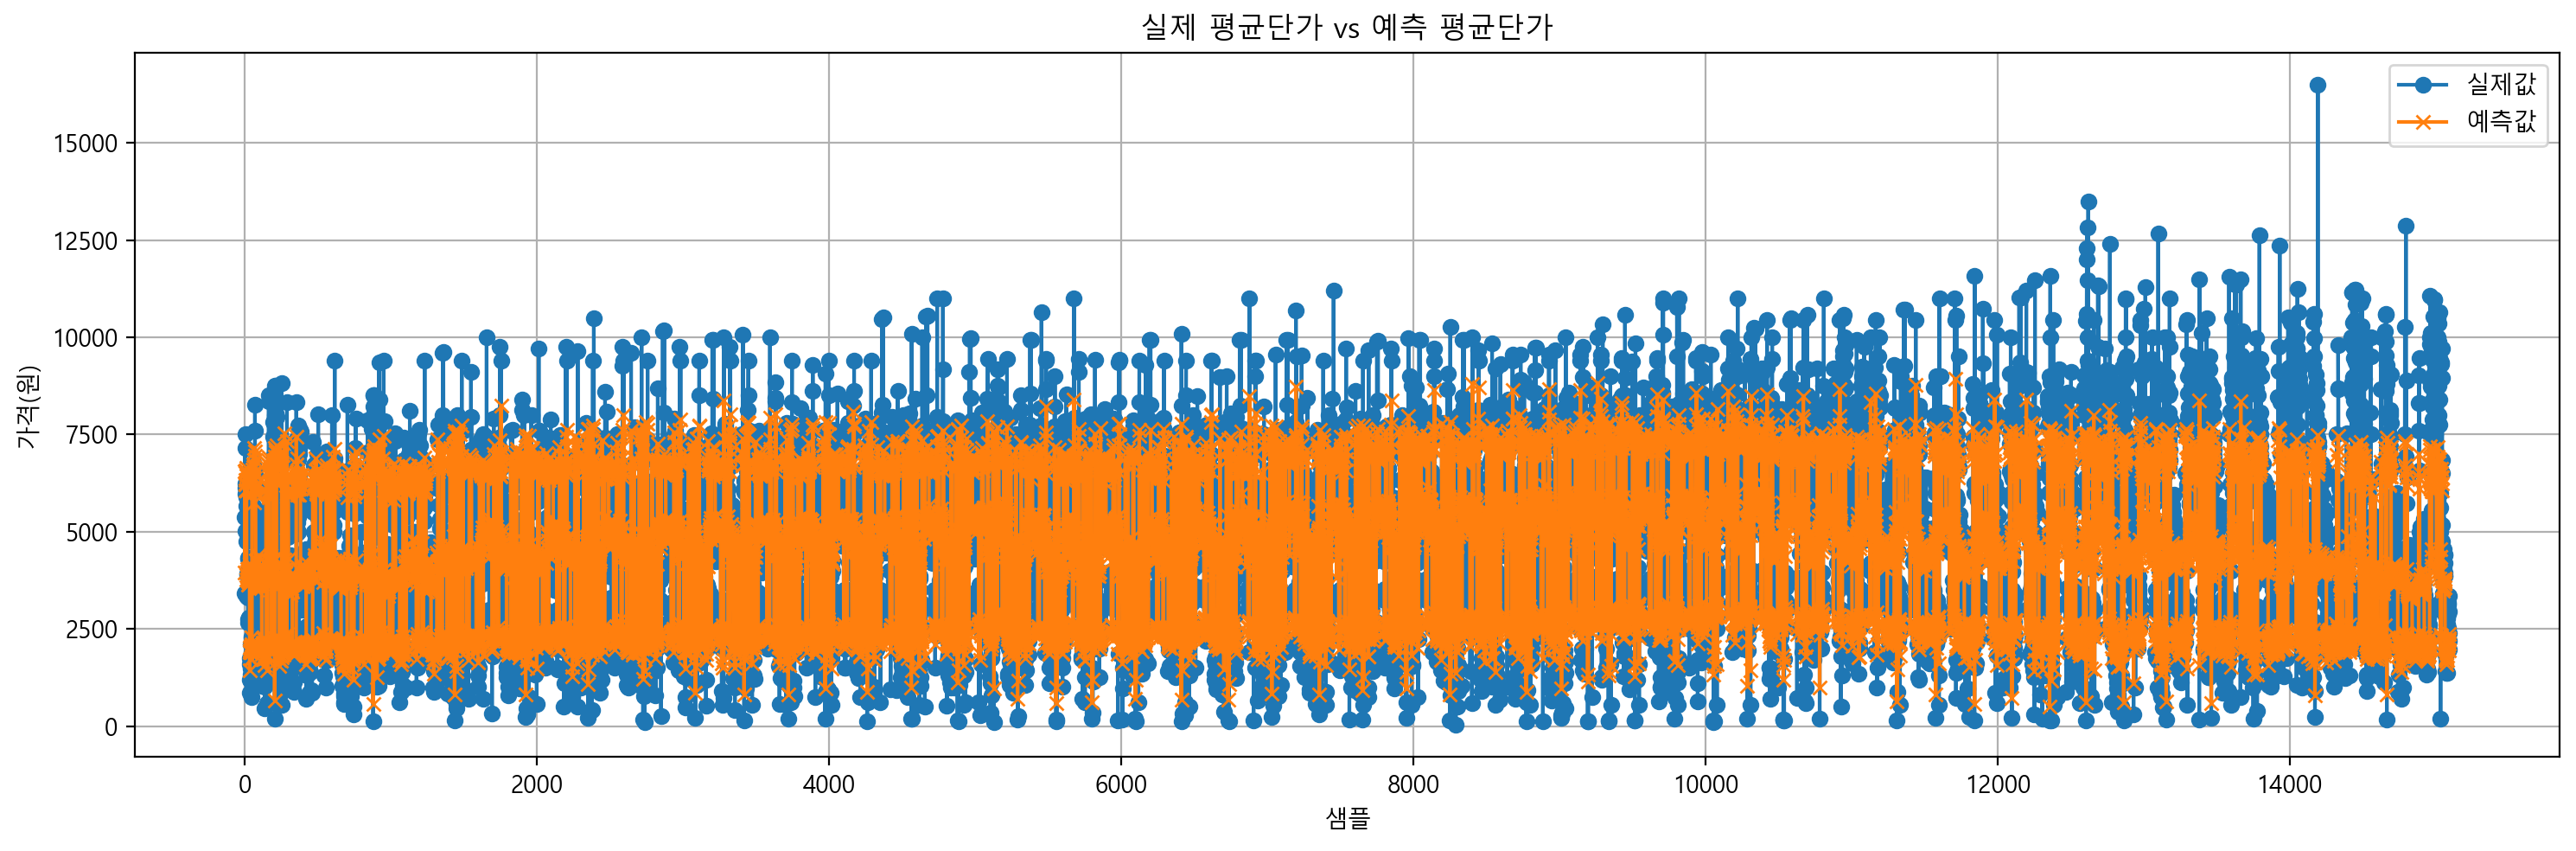

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(test_y.values, label='실제값', marker='o')
plt.plot(y_pred, label='예측값', marker='x')
plt.title("실제 평균단가 vs 예측 평균단가")
plt.xlabel("샘플")
plt.ylabel("가격(원)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

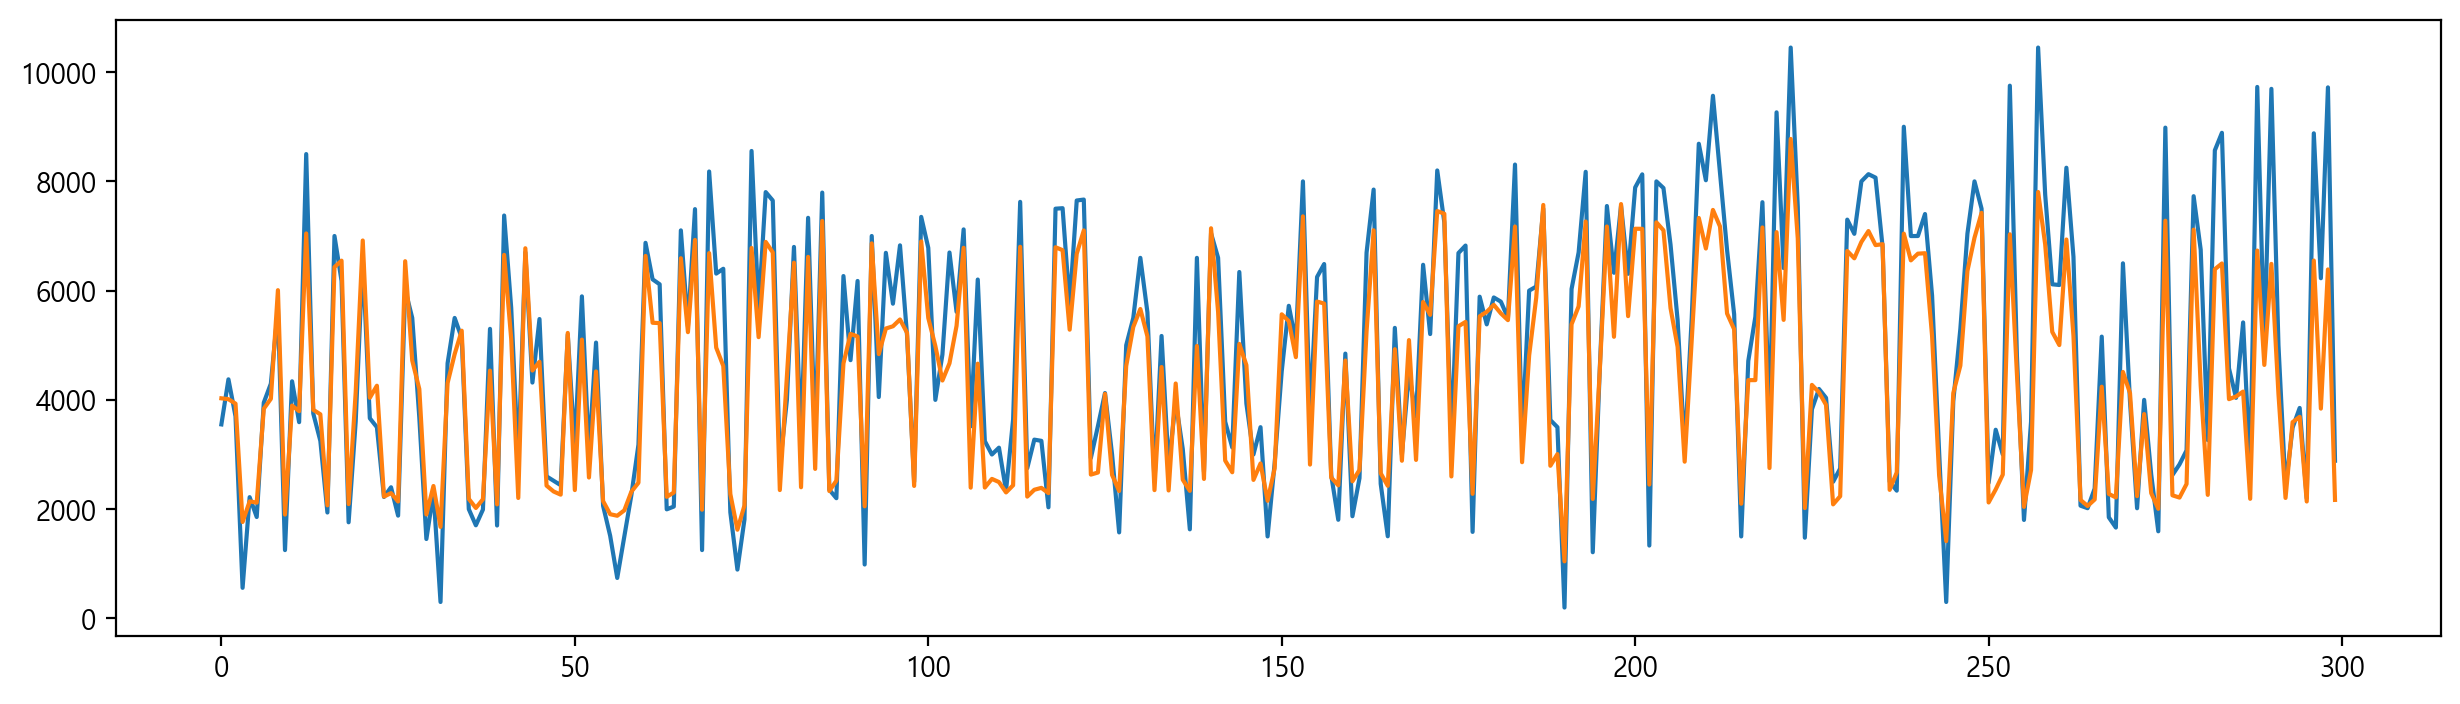

In [121]:
# 샘플 추려서 보기
sample = test_y.sample(300, random_state=42).sort_index()
sample_pred = model.predict(test_X.loc[sample.index])

plt.figure(figsize=(15,4))
plt.plot(sample.values, label='실제')
plt.plot(sample_pred, label='예측')

In [109]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf.feature_importances_
feat_names = X_train.columns
pd.Series(importance, index=feat_names).sort_values().plot.barh()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

NameError: name 'rf' is not defined

## 2차 랜덤포레스트 (빡세게 튜닝)

In [122]:
# 조금 더 올려서 해보기
model = RandomForestRegressor(
    n_estimators=1000,         # 트리 수 늘리기
    max_depth=None,            # 깊이 제한 없이 과적합 허용
    min_samples_leaf=1,        # 리프에 최소 샘플 1개
    min_samples_split=2,       # 분할 최소 샘플 수
    max_features='sqrt',       # 피처 일부 무작위 선택
    n_jobs=-1,
    random_state=77,
    verbose=1                  # 진행 상황 출력
)
model.fit(train_X, train_y)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 776 tasks      | elapsed:   24.3s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   31.1s finished


RandomForestRegressor(max_features='sqrt', n_estimators=1000, n_jobs=-1,
                      random_state=77, verbose=1)

In [123]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(test_X)
rmse = mean_squared_error(test_y, y_pred, squared=False)
print(f"RMSE: {rmse:.2f} 원")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.1s


RMSE: 870.25 원


[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 1000 out of 1000 | elapsed:    0.3s finished


In [124]:
from sklearn.metrics import r2_score

r2 = r2_score(test_y, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.8456


## 3차 GridSCV

In [126]:
from sklearn.model_selection import GridSearchCV

In [193]:
print(type(train_X))
print(type(train_y))
print(train_X.dtypes)
print(train_X.columns)

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
품종코드               int64
등급코드               int64
직팜산지코드             int64
총거래량(kg)         float64
일평균기온            float64
최고기온             float64
최저기온             float64
평균상대습도           float64
강수량(mm)          float64
1시간최고강수량(mm)     float64
holiday_flag       int64
holiday_score    float64
grow_score       float64
year               int64
week               int64
dtype: object
Index(['품종코드', '등급코드', '직팜산지코드', '총거래량(kg)', '일평균기온', '최고기온', '최저기온', '평균상대습도',
       '강수량(mm)', '1시간최고강수량(mm)', 'holiday_flag', 'holiday_score',
       'grow_score', 'year', 'week'],
      dtype='object')


In [173]:
df['week_start'] = pd.to_datetime(df_weekly_galic['week_start'])
df.drop(columns='weekno', inplace=True)

KeyError: "['weekno'] not found in axis"

In [188]:
df.drop(columns='week_start', inplace=True)

In [184]:
df['year'] = df['year'].astype(np.int64)
df['week'] = df['week'].astype(np.int64)

In [191]:
# 학습/검증데이터 분리
# 훈련 데이터: 2018년부터 2023년 말까지
train_set = df[df['year'] < 2024 ]

# 검증 데이터: 2024년
val_set = df[(df['year'] == 2024) ]

# 테스트 또는 예측 대상: 2025년
test_set = df[df['year'] >= 2025 ]


train_X = train_set.iloc[:, :-1]
train_y = train_set.iloc[:, -1]
val_X = val_set.iloc[:, :-1]
val_y = val_set.iloc[:, -1]
test_X = test_set.iloc[:, :-1]
test_y = test_set.iloc[:, -1]

In [199]:
%%time
# GridSearchCV 를 통한 파라미터 탐색
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 3],
    'max_samples' : [ 0.8, 1]
}

grid = GridSearchCV(RandomForestRegressor(random_state=77), param_grid, cv=3, n_jobs=1)
grid.fit(train_X, train_y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 20, 'max_samples': 0.8, 'min_samples_leaf': 1, 'n_estimators': 500}
Best Score: 0.41817303117909627
CPU times: total: 53min 43s
Wall time: 54min 10s


## 스케일 추가